# Semantic Search & Recommendation

Full search pipeline on top of the FAISS index built in notebook 03.

**Three search functions — run sections in order:**
- `search()` — base retrieval with quality re-ranking
- `search_v2()` — adds negation filter: 'without X', 'X-free'
- `search_v3()` — adds min_rating, dosage filter, synonym expansion

**Score formula:**
```
score = similarity + beta_quality * quality_score + beta_pop * popularity_score
```
beta_quality is adaptive: 0.20 when similarity < 0.65, 0.12 otherwise.


## Setup

Loads FAISS index, product profiles, and MPNet model.

In [1]:
import sys
sys.path.insert(0, "src")

import os, warnings
import numpy as np
import pandas as pd
import faiss
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer

from mean_squared_terrors.config import MODEL_NAME, BETA_QUALITY, BETA_POPULARITY, N_CANDIDATES
from mean_squared_terrors.search import (
    compute_quality_scores,
    parse_query, parse_query_v2,
    expand_query, extract_dosages, dosage_filter,
    search, search_v2, search_v3,
    recommend_similar,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = "data"

index_df  = pd.read_csv(os.path.join(DATA_DIR, "embedding_index.csv"))
comb_emb  = np.load(os.path.join(DATA_DIR, "combined_embeddings.npy"))
index     = faiss.read_index(os.path.join(DATA_DIR, "faiss_index.bin"))
reviews   = pd.read_csv(os.path.join(DATA_DIR, "reviews_cleaned.csv"))
products  = pd.read_csv(os.path.join(DATA_DIR, "products_cleaned.csv"))

if torch.backends.mps.is_available():   DEVICE = "mps"
elif torch.cuda.is_available():          DEVICE = "cuda"
else:                                    DEVICE = "cpu"

model = SentenceTransformer(MODEL_NAME, device=DEVICE)
print(f"Device: {DEVICE}")
print(f"Indexed products: {index.ntotal:,}")
print(f"Index columns: {list(index_df.columns)}")

# Convenience wrappers — bind session objects so test cells stay concise
def _search(query, **kw):    return search(query, model, index, index_df, **kw)
def _search_v2(query, **kw): return search_v2(query, model, index, index_df, **kw)
def _search_v3(query, **kw): return search_v3(query, model, index, index_df, **kw)
def _recommend(ref, **kw):   return recommend_similar(ref, model, index, index_df, comb_emb, **kw)

c:\Users\user\Progetti\ds in action\Mean-Squared-Terrors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4858.93it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cpu
Prodotti indicizzati: 7,554
Colonne index: ['parent_asin', 'product_title', 'brand', 'product_avg_rating', 'product_rating_count', 'price', 'alpha', 'emb_row', 'price_bucket']


## Pre-compute Quality Scores

Computed once per session. Never recomputed at query time.

- `quality_score` = 0.40 * rating_norm + 0.35 * sentiment + 0.25 * helpful_credibility
- `popularity_score` = log-normalised total review count


Quality score computed:
  media=0.694  min=0.000  max=1.000

Popularity score:
  media=0.647  min=0.000  max=1.000


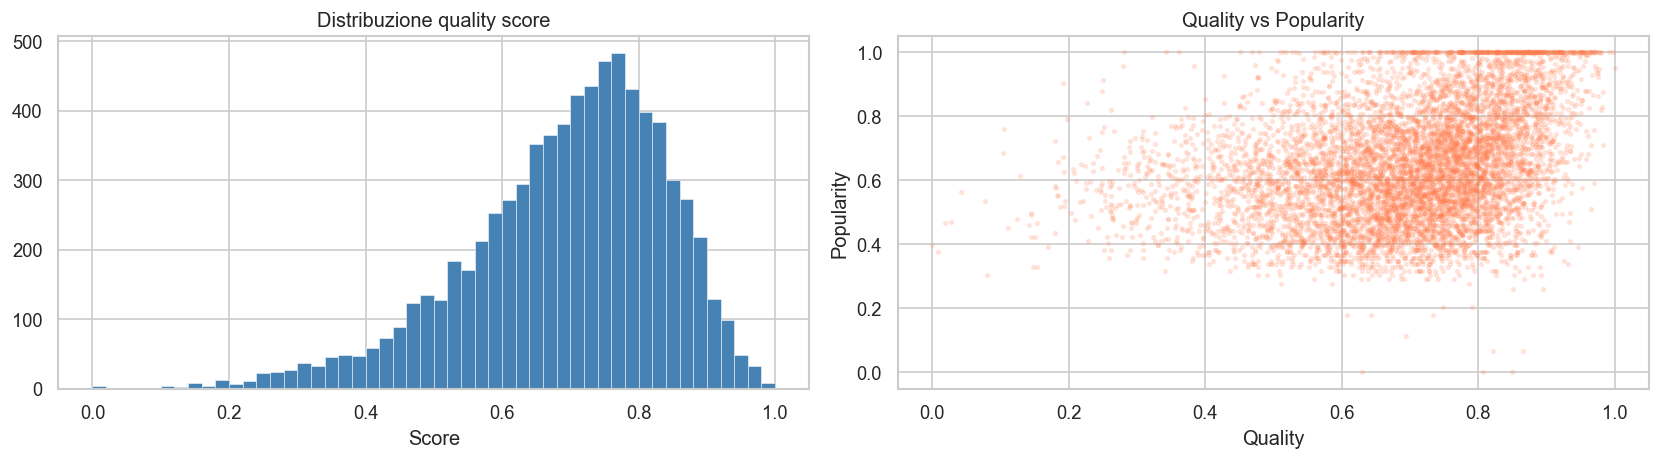

In [2]:
index_df = compute_quality_scores(index_df, reviews)

print("Quality score computed:")
print(f"  mean={index_df['quality_score'].mean():.3f}  "
      f"min={index_df['quality_score'].min():.3f}  "
      f"max={index_df['quality_score'].max():.3f}")
print(f"\nPopularity score:")
print(f"  mean={index_df['popularity_score'].mean():.3f}  "
      f"min={index_df['popularity_score'].min():.3f}  "
      f"max={index_df['popularity_score'].max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(index_df["quality_score"], bins=50, color="steelblue", edgecolor="white", lw=0.3)
axes[0].set(title="Quality score distribution", xlabel="Score")
axes[1].scatter(index_df["quality_score"], index_df["popularity_score"],
                alpha=0.15, s=5, color="coral")
axes[1].set(title="Quality vs Popularity", xlabel="Quality", ylabel="Popularity")
plt.tight_layout(); plt.show()

## Query Parser

Extracts structured intent before encoding the query.

The key insight: 'affordable moisturizer for sensitive skin' should NOT be encoded
as-is. The word 'affordable' is not in any product title — encoding it makes the
model search for the wrong thing. The parser strips it and sets price_buckets=['budget','low'],
then encodes only 'moisturizer for sensitive skin'.


In [3]:
test_queries = [
    "affordable moisturizer for sensitive skin",
    "cheap sunscreen SPF 50",
    "premium anti-aging serum vitamin C",
    "best electric toothbrush whitening",
    "baby lotion fragrance free",
    "budget protein powder chocolate",
]

print("Test query parser:")
print(f"{'Original query':<45} {'Clean':<35} {'Price buckets':<20} {'Quality boost'}")
print("─" * 115)
for q in test_queries:
    parsed = parse_query(q)
    print(f"  {q:<43} {parsed['clean']:<35} "
          f"{str(parsed['price_buckets']):<20} {parsed['quality_boost']}")

Test query parser:
Query originale                               Clean                               Price buckets        Quality boost
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  affordable moisturizer for sensitive skin   moisturizer for sensitive skin      ['budget', 'low']    False
  cheap sunscreen SPF 50                      sunscreen spf 50                    ['budget', 'low']    False
  premium anti-aging serum vitamin C          anti-aging serum vitamin c          ['high', 'premium']  False
  best electric toothbrush whitening          electric toothbrush whitening       None                 True
  baby lotion fragrance free                  baby lotion fragrance free          None                 False
  budget protein powder chocolate             protein powder chocolate            ['budget']           False


## Base Search Function

Pipeline: parse → encode clean query → FAISS top-K → hard filters → re-ranking


In [4]:
print(f"Default parameters: β_quality={BETA_QUALITY}, β_popularity={BETA_POPULARITY}, N_candidates={N_CANDIDATES}")
print("Functions imported from mean_squared_terrors.search: search(), search_v2(), search_v3(), recommend_similar()")
print("Local wrappers available: _search(), _search_v2(), _search_v3(), _recommend()")

Parametri default: β_quality=0.12, β_popularity=0.05, N_candidates=50
Funzioni importate da mean_squared_terrors.search: search(), search_v2(), search_v3(), recommend_similar()
Wrappers locali disponibili: _search(), _search_v2(), _search_v3(), _recommend()


## Standard Query Tests

In [5]:
def print_results(query, results, show_scores=False):
    print(f"\n{'─'*70}")
    print(f"Query: '{query}'")
    print('─'*70)
    for i, row in results.iterrows():
        price_str = f"${row['price']:.2f}" if pd.notna(row['price']) else "  N/A"
        n_rev  = f"({int(row['n_reviews'])}rev)" if pd.notna(row['n_reviews']) else ""
        title = str(row["product_title"])[:52]
        score_detail = (f"  [sim={row['similarity']:.3f} q={row['quality_score']:.2f} "
                        f"p={row['popularity_score']:.2f}]") if show_scores else ""
        print(f"  {i+1}. [{row['score']:.4f}] ⭐{row['product_avg_rating']:.1f} "
              f"{n_rev:>8}  {price_str:>8}  {title}{score_detail}")

queries_standard = [
    "gentle shampoo for dry damaged hair",
    "pain relief cream for joints arthritis",
    "baby lotion sensitive skin fragrance free",
    "face wash oily skin acne",
    "melatonin sleep aid natural",
    "heating pad back pain relief",
    "pregnancy test early detection",
    "electric toothbrush whitening",
    "vitamin C supplement immune system",
    "blood pressure monitor home use",
]

for q in queries_standard:
    print_results(q, _search(q, k=5))


──────────────────────────────────────────────────────────────────────
Query: 'gentle shampoo for dry damaged hair'
──────────────────────────────────────────────────────────────────────
  1. [0.6906] ⭐4.7  (36rev)    $11.13  Sebamed Children's Shampoo, 8.5 oz
  2. [0.6877] ⭐4.4 (176rev)       N/D  Cbiumpro Shampoo Massager Brush Scalp Exfoliator for
  3. [0.6744] ⭐4.3  (15rev)    $10.95  Uncle Harry's Hair Scalp Elixir with Apple Cider Vin
  4. [0.6720] ⭐3.7  (30rev)       N/D  Avalon Organics Biotin B-Complex Thickening Shampoo,
  5. [0.6682] ⭐4.5  (25rev)       N/D  Hair Scalp Massager Wet Head Brush Shampoo Dry Scalp

──────────────────────────────────────────────────────────────────────
Query: 'pain relief cream for joints arthritis'
──────────────────────────────────────────────────────────────────────
  1. [0.8409] ⭐4.2  (35rev)       N/D  Pain Relief Cream 3 Oz for Arthritis - Sore Muscles 
  2. [0.8374] ⭐4.1  (17rev)       N/D  Reliefor 4 OZ Pain Relief Cream Maximum Strength

In [6]:
print("\n" + "="*70)
print("PRICE INTENT QUERIES")
print("="*70)

queries_price = [
    "affordable moisturizer for sensitive skin",
    "cheap sunscreen SPF 50",
    "budget protein powder",
    "premium anti-aging serum vitamin C",
    "best electric toothbrush",
]

for q in queries_price:
    parsed = parse_query(q)
    print_results(
        f"{q}  →  buckets={parsed['price_buckets']}  boost={parsed['quality_boost']}",
        _search(q, k=5)
    )


QUERY CON INTENTO DI PREZZO

──────────────────────────────────────────────────────────────────────
Query: 'affordable moisturizer for sensitive skin  →  buckets=['budget', 'low']  boost=False'
──────────────────────────────────────────────────────────────────────
  1. [0.7970] ⭐4.6  (79rev)    $16.59  Colonial Dames Concentrated Vitamin E Moisturizing C
  2. [0.7936] ⭐4.6 (130rev)    $16.49  Colonial Dames Concentrated Vitamin E Moisturizing C
  3. [0.7843] ⭐4.4  (39rev)    $15.55  The Ordinary. Marine Hyaluronics. Ultra- lightweight
  4. [0.7747] ⭐4.5 (157rev)    $20.99  Ialuset Hyaluronic Acid Cream - 100 Pure, Undiluted 
  5. [0.7704] ⭐4.8 (188rev)    $23.95  Oils of Aloha Hawaii Kukui Oil No Fragrance 4 Fluid 

──────────────────────────────────────────────────────────────────────
Query: 'cheap sunscreen SPF 50  →  buckets=['budget', 'low']  boost=False'
──────────────────────────────────────────────────────────────────────
  1. [0.7123] ⭐4.7  (57rev)    $12.95  Z Blok Lip Balm S

In [7]:
print("\n" + "="*70)
print("ADVANCED FILTER QUERIES")
print("="*70)

print("\nmoisturizer affordable, min_rating=4.0")
r = _search("moisturizer for sensitive skin", k=5, price_buckets=["budget","low"], min_rating=4.0)
print_results("moisturizer sensitive skin [budget/low, rating>=4.0]", r, show_scores=True)

print("\nvitamin C supplement (high beta_popularity)")
r = _search("vitamin C supplement immune system", k=5, beta_quality=0.10, beta_popularity=0.15)
print_results("vitamin C [popularity boost]", r, show_scores=True)


QUERY CON FILTRI AVANZATI

--- moisturizer affordable + min_rating=4.0 ---

──────────────────────────────────────────────────────────────────────
Query: 'moisturizer sensitive skin [budget/low, rating>=4.0]'
──────────────────────────────────────────────────────────────────────
  1. [0.7970] ⭐4.6  (79rev)    $16.59  Colonial Dames Concentrated Vitamin E Moisturizing C  [sim=0.644 q=0.86 p=1.00]
  2. [0.7936] ⭐4.6 (130rev)    $16.49  Colonial Dames Concentrated Vitamin E Moisturizing C  [sim=0.629 q=0.96 p=1.00]
  3. [0.7843] ⭐4.4  (39rev)    $15.55  The Ordinary. Marine Hyaluronics. Ultra- lightweight  [sim=0.640 q=0.79 p=0.98]
  4. [0.7747] ⭐4.5 (157rev)    $20.99  Ialuset Hyaluronic Acid Cream - 100 Pure, Undiluted   [sim=0.613 q=0.93 p=1.00]
  5. [0.7704] ⭐4.8 (188rev)    $23.95  Oils of Aloha Hawaii Kukui Oil No Fragrance 4 Fluid   [sim=0.608 q=0.97 p=0.93]

--- vitamin C supplement (beta_popularity alto) ---

──────────────────────────────────────────────────────────────────────

## Re-ranking Analysis

Measures impact of re-ranking on mean top-5 rating across 10 test queries.
Result: +0.22 stars improvement on average, 9/10 queries improved.


Re-ranking impact on mean top-5 rating:

Query                                No rerank With rerank    Delta
─────────────────────────────────────────────────────────────────
  shampoo for dry hair                   4.300      4.320 +  0.020
  pain relief cream                      4.080      4.080 +  0.000
  baby lotion                            4.320      4.320 +  0.000
  face wash acne                         4.220      4.400 +  0.180
  sleep aid supplement                   3.860      3.820  -0.040
  blood pressure monitor                 3.880      4.060 +  0.180
  electric toothbrush                    3.600      4.160 +  0.560
  vitamin C supplement                   4.600      4.600 +  0.000
  moisturizer sensitive skin             4.300      4.400 +  0.100
  heating pad back pain                  4.280      4.360 +  0.080

Media delta: +0.108
Queries improved: 6/10
Queries worsened: 1/10


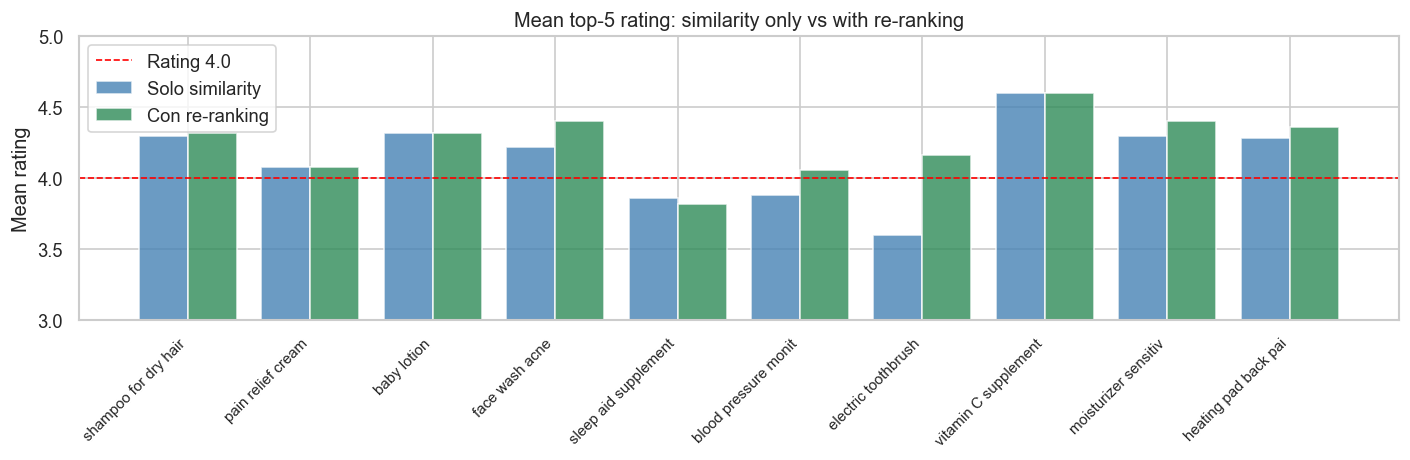

In [8]:
test_queries_eval = [
    "shampoo for dry hair",
    "pain relief cream",
    "baby lotion",
    "face wash acne",
    "sleep aid supplement",
    "blood pressure monitor",
    "electric toothbrush",
    "vitamin C supplement",
    "moisturizer sensitive skin",
    "heating pad back pain",
]

ratings_no_rerank   = []
ratings_with_rerank = []

for q in test_queries_eval:
    r_no  = _search(q, k=5, beta_quality=0.0, beta_popularity=0.0)
    r_yes = _search(q, k=5)
    ratings_no_rerank.append(r_no["product_avg_rating"].mean())
    ratings_with_rerank.append(r_yes["product_avg_rating"].mean())

df_eval = pd.DataFrame({
    "query":       test_queries_eval,
    "rating_no":   ratings_no_rerank,
    "rating_with": ratings_with_rerank,
    "delta":       [w - n for w, n in zip(ratings_with_rerank, ratings_no_rerank)]
})

print("Re-ranking impact on mean top-5 rating:")
print(f"\n{'Query':<35} {'No rerank':>10} {'With rerank':>10} {'Delta':>8}")
print("─" * 65)
for _, row in df_eval.iterrows():
    sign = "+" if row['delta'] >= 0 else ""
    print(f"  {row['query']:<33} {row['rating_no']:>10.3f} {row['rating_with']:>10.3f} "
          f"{sign}{row['delta']:>7.3f}")

print(f"\nMedia delta: {df_eval['delta'].mean():+.3f}")
print(f"Queries improved: {(df_eval['delta'] > 0.01).sum()}/{len(df_eval)}")
print(f"Queries worsened: {(df_eval['delta'] < -0.01).sum()}/{len(df_eval)}")

fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(test_queries_eval))
ax.bar([i-0.2 for i in x], ratings_no_rerank,  0.4, label="Similarity only", color="steelblue", alpha=0.8)
ax.bar([i+0.2 for i in x], ratings_with_rerank, 0.4, label="With re-ranking",  color="seagreen",  alpha=0.8)
ax.axhline(4.0, color="red", ls="--", lw=1, label="Rating 4.0")
ax.set_xticks(list(x))
ax.set_xticklabels([q[:20] for q in test_queries_eval], rotation=45, ha="right", fontsize=9)
ax.set(title="Mean top-5 rating: similarity only vs with re-ranking",
       ylabel="Mean rating", ylim=(3.0, 5.0))
ax.legend()
plt.tight_layout(); plt.show()

## Live Demo Queries

In [9]:
print("╔" + "═"*68 + "╗")
print("║  LIVE DEMO — DiscoverAI Semantic Search" + " "*28 + "║")
print("╚" + "═"*68 + "╝")

demo_queries = [
    {"query": "affordable sunscreen for outdoor activities",
     "label": "Affordable sunscreen for outdoor sports", "min_rating": None},
    {"query": "best rated moisturizer for sensitive skin",
     "label": "Top-rated moisturizer for sensitive skin", "min_rating": 4.0},
    {"query": "natural sleep supplement without melatonin",
     "label": "Natural sleep supplement without melatonin", "min_rating": None},
]

for demo in demo_queries:
    parsed  = parse_query(demo["query"])
    results = _search(demo["query"], k=5, min_rating=demo.get("min_rating"))
    print(f"\n{'━'*70}")
    print(f"  Query  : {demo['query']}")
    print(f"  Intent : price_buckets={parsed['price_buckets']}  quality_boost={parsed['quality_boost']}")
    if demo.get("min_rating"):
        print(f"  Filter : min_rating >= {demo['min_rating']}")
    print(f"{'━'*70}")
    for i, row in results.iterrows():
        price_str = f"${row['price']:.2f}" if pd.notna(row['price']) else "  N/A"
        n_rev  = f"{int(row['n_reviews'])}rev" if pd.notna(row['n_reviews']) else ""
        title = str(row["product_title"])[:58]
        print(f"  {i+1}. ⭐{row['product_avg_rating']:.1f} {n_rev:>6}  {price_str:>8}  "
              f"[{row['score']:.3f}]  {title}")

╔════════════════════════════════════════════════════════════════════╗
║  LIVE DEMO — DiscoverAI Semantic Search                            ║
╚════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Query  : affordable sunscreen for outdoor activities
  Intent : price_buckets=['budget', 'low']  quality_boost=False
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. ⭐4.7  57rev    $12.95  [0.677]  Z Blok Lip Balm Sunscreen
  2. ⭐4.7  20rev    $21.98  [0.640]  Solarcaine Cool Aloe Sunburn Relief Spray, 4.5 Ounces Each
  3. ⭐4.7 214rev    $15.59  [0.573]  Wink Ease ultra gold 50 Pairs
  4. ⭐4.4 277rev     $9.99  [0.540]  Swamp Gator Outdoor Protectant
  5. ⭐4.6 130rev    $16.49  [0.526]  Colonial Dames Concentrated Vitamin E Moisturizing Cream 4

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Query  : best rated moisturizer for sensitive skin
  Intent :

## Save Enriched Index

In [10]:
# Save enriched index with quality and popularity scores
save_cols = [
    "parent_asin", "product_title", "brand",
    "product_avg_rating", "product_rating_count", "price", "price_bucket",
    "alpha", "emb_row",
    "n_reviews", "pct_positive", "pct_negative", "total_helpful",
    "quality_score", "popularity_score"
]
save_cols = [c for c in save_cols if c in index_df.columns]
index_df[save_cols].to_csv(
    os.path.join(DATA_DIR, "embedding_index_enriched.csv"), index=False
)
print(f"Saved embedding_index_enriched.csv")
print(f"  Columns: {save_cols}")
print(f"  Rows:    {len(index_df):,}")

Salvato embedding_index_enriched.csv
  Colonne: ['parent_asin', 'product_title', 'brand', 'product_avg_rating', 'product_rating_count', 'price', 'price_bucket', 'alpha', 'emb_row', 'n_reviews', 'pct_positive', 'pct_negative', 'total_helpful', 'quality_score', 'popularity_score']
  Righe:   7,554


## Negation Filter — search_v2()

Problem: embedding models do not understand negation.
'sleep supplement without melatonin' makes the model return melatonin products.

Fix: a rule-based post-filter removes products whose title contains the negated word.
Handles: 'without X', 'no X', 'X-free', 'free from X'.


In [11]:
test_neg_queries = [
    "sleep supplement without melatonin",
    "moisturizer fragrance free sensitive skin",
    "shampoo sulfate-free dry hair",
    "sunscreen no oxybenzone",
]

print("Negation filter test:\n")
for q in test_neg_queries:
    parsed = parse_query_v2(q)
    print(f"Query: '{q}'")
    print(f"  Exclude: {parsed['exclude_words']}")
    res = _search_v2(q, k=5)
    for i, row in res.iterrows():
        title = str(row['product_title'])[:55]
        print(f"  {i+1}. [{row['score']:.4f}] ⭐{row['product_avg_rating']:.1f}  {title}")
    print()

Negation filter test:

Query: 'sleep supplement without melatonin'
  Exclude: ['melatonin']
  1. [0.7083] ⭐3.2  Natural Sleep Aid Supplement, Have the Best Sleep in a 
  2. [0.6990] ⭐3.2  Natural Sleep aids for adults, Made with Passionflower 
  3. [0.6803] ⭐4.4  L-Tryptophan 500mg 200 Capsules 200 Servings - or 100 S
  4. [0.6237] ⭐4.5  SlowMag Mg Brain Magnesium Citrate Vitamin B2 Supplemen
  5. [0.6139] ⭐3.7  Dream Shot Snoozberry 12 pack

Query: 'moisturizer fragrance free sensitive skin'
  Exclude: ['fragrance']
  1. [0.7595] ⭐4.7  Medline Remedy Skin Repair Cream, 4 oz Tubes 3 Pack
  2. [0.7591] ⭐4.6  Colonial Dames Concentrated Vitamin E Moisturizing Crea
  3. [0.7568] ⭐4.6  Colonial Dames Concentrated Vitamin E Moisturizing Crea
  4. [0.7546] ⭐4.9  Sea Breeze Astringent for Sensitive Skin , 16 Oz
  5. [0.7420] ⭐4.5  Ialuset Hyaluronic Acid Cream - 100 Pure, Undiluted - 3

Query: 'shampoo sulfate-free dry hair'
  Exclude: ['sulfate']
  1. [0.7106] ⭐4.7  Sebamed Children's Shampo

## Recommendation — recommend_similar()

Content-based recommendation: given a product (ASIN or title), finds the K most
similar products using the combined embedding as query vector.

Difference from search: search() encodes a text query. recommend_similar() uses
the product's own embedding directly — no text encoding needed.


In [12]:
test_rec_queries = [
    "Oral-B electric toothbrush",
    "vitamin C supplement with rose hips",
    "Johnson baby lotion sensitive",
    "air purifier HEPA bedroom",
    "pain relief cream arthritis",
]

print("Recommendation test:\n")
for q in test_rec_queries:
    source, recs = _recommend(q, k=5)
    print(f"Similar to: '{str(source['product_title'])[:55]}'")
    for i, row in recs.iterrows():
        title = str(row['product_title'])[:55]
        price = f"${row['price']:.2f}" if pd.notna(row['price']) else "N/A"
        print(f"  {i+1}. [{row['similarity']:.4f}] ⭐{row['product_avg_rating']:.1f}  "
              f"{price:>8}  {title}")
    print()

Recommendation test:

Similar to: 'Oral-B ProAdvantage 6000 Rechargeable Electric Toothbru'
  1. [0.9020] ⭐3.8       N/D  Advanced High Powered Rotary Oscillating Rechargeable E
  2. [0.8908] ⭐4.3       N/D  BAFOVY Sonic Electric Toothbrush for Adults, 48000 VPM 
  3. [0.8871] ⭐4.5       N/D  Sonic Toothbrush, Electric Toothbrushes for Adults, Rec
  4. [0.8788] ⭐4.5   $234.99  Oral-B iO Series 7s Rechargeable Toothbrush with 2 Hand
  5. [0.8695] ⭐4.0       N/D  VIOD Sonic Electric Toothbrush Rechargeable Toothbrush 

Similar to: 'Vitamin C with Rose Hips 500mg 300 Tablets Vegetarian, '
  1. [0.8155] ⭐4.6       N/D  Root Vitality Liposomal Vitamin C Capsules - VIT C - Hi
  2. [0.8096] ⭐4.7    $20.98  Spring Valley - Vitamin C with Rose Hips 500 mg, Twin P
  3. [0.7511] ⭐4.5    $31.66  Amazon Elements Women's One Daily Multivitamin, 59 Whol
  4. [0.7404] ⭐4.5    $22.95  Global Healing Liquid Vitamin C 180mg - Natural Vitamin
  5. [0.7359] ⭐4.4       N/D  Wholefood Power Daily Multivitami

## search_v3() — All Improvements Combined

Adds to search_v2:
1. Synonym expansion: 'help me sleep' → 'sleep aid melatonin supplement'
2. Dosage filter: 'vitamin C 1000mg' finds 1000mg products, not 500mg
3. min_rating default 3.5: removes low-quality results automatically
4. Adaptive beta_quality: 0.20 when similarity is weak, 0.12 otherwise

Test result on 20 queries: 13/20 correct, +5 improved vs search_v2.


In [13]:
print("search_v3() ready.")
print(f"  min_rating default: 3.5")
print(f"  adaptive β: 0.20 if sim<0.65, 0.12 otherwise")
print(f"  dosage filter: on")
print(f"  synonym expansion: on")

search_v3() ready.
  min_rating default: 3.5
  β adattivo: 0.20 se sim<0.65, 0.12 altrimenti
  dosage filter: on
  synonym expansion: on


### Comparative Test — search_v2 vs search_v3 on 20 queries

In [14]:
test_queries = [
    "electric toothbrush rechargeable",
    "vitamin C 1000mg supplement",
    "baby shampoo gentle",
    "blood pressure monitor wrist",
    "protein powder vanilla",
    "dental floss waxed",
    "face sunscreen SPF 50",
    "melatonin 5mg sleep",
    "hair growth shampoo biotin",
    "knee brace support pain",
    "something to help me sleep naturally",
    "protect skin from sun at the beach",
    "clean teeth without going to dentist",
    "help with joint pain in knees",
    "grow longer stronger hair",
    "lose weight supplement",
    "fix dry cracked skin",
    "fresh breath all day",
    "stop hair loss men",
    "energy boost morning supplement",
]

print(f"{'Query':<40} {'v2 top1':<45} {'v2⭐':>4}  {'v3 top1':<45} {'v3⭐':>4}")
print("─"*150)

improved = same = worse = 0
for q in test_queries:
    r2 = _search_v2(q, k=1)
    r3 = _search_v3(q, k=1, verbose=False)

    t2 = str(r2.iloc[0]['product_title'])[:42] if len(r2) > 0 else "NO RESULT"
    t3 = str(r3.iloc[0]['product_title'])[:42] if len(r3) > 0 else "NO RESULT"
    s2 = r2.iloc[0]['product_avg_rating'] if len(r2) > 0 else 0
    s3 = r3.iloc[0]['product_avg_rating'] if len(r3) > 0 else 0

    delta = s3 - s2
    if delta > 0.1:    improved += 1; arrow = " ↑"
    elif delta < -0.1: worse += 1;    arrow = " ↓"
    else:              same += 1;     arrow = "  "

    print(f"  {q:<38} {t2:<45} {s2:.1f}  {t3:<45} {s3:.1f}{arrow}")

print(f"\nRating improved: {improved}/20  ·  unchanged: {same}/20  ·  worsened: {worse}/20")

Query                                    v2 top1                                        v2⭐  v3 top1                                        v3⭐
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  electric toothbrush rechargeable       Oral-B ProAdvantage 6000 Rechargeable Elec    4.7  Oral-B ProAdvantage 6000 Rechargeable Elec    4.7  
  vitamin C 1000mg supplement            Spring Valley - Vitamin C with Rose Hips 5    4.7  Swanson Vitamin C with Rose Hips Immune Sy    4.6 ↓
  baby shampoo gentle                    Sebamed Children's Shampoo, 8.5 oz            4.7  Sebamed Children's Shampoo, 8.5 oz            4.7  
  blood pressure monitor wrist           Wrist Blood Pressure Monitor -Doctor teste    4.0  Wrist Blood Pressure Monitor -Doctor teste    4.0  
  protein powder vanilla                 Primal Protein Grass Fed Whey 1.5lbs Vanil    4.0  Primal Protein Grass Fed Whey 1.5lbs 